In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir('/content/drive/MyDrive/colab')

['placement_predict_50k.csv',
 'placement_dataset.csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'indexData.csv']

In [4]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/colab/indexData.csv')

Iteration    0 | Loss: 69757442.8300
Iteration  100 | Loss: 3946720.5439
Iteration  200 | Loss: 529034.0109
Iteration  300 | Loss: 72522.3875
Iteration  400 | Loss: 11349.4154
Iteration  500 | Loss: 3151.8062
Iteration  600 | Loss: 2053.0049
Iteration  700 | Loss: 1905.4669
Iteration  800 | Loss: 1885.4025
Iteration  900 | Loss: 1882.4204

Final weights (theta):
[ 7.65159955e+03  2.24542432e+03  2.24911285e+03  2.24973885e+03
  2.25368666e+03 -2.94366738e-01]

Test MSE : 3634.8993
Test R^2 : 1.0000

sklearn LinearRegression R^2: 1.0000

Saved plots to gradient_descent_plots.png


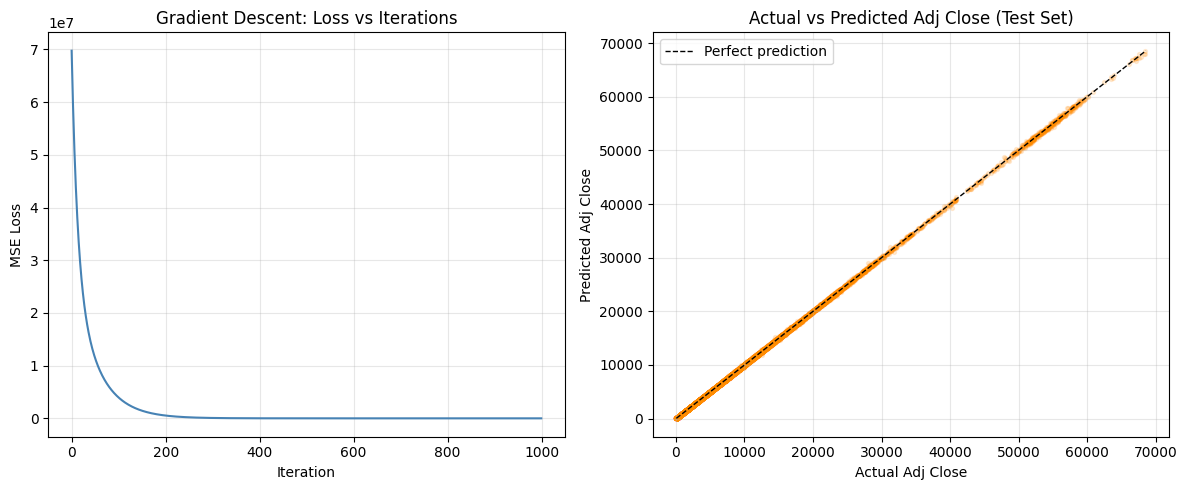

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------------------------------------
# 1. Load and Clean Data
# ---------------------------------------------------------
df = pd.read_csv('/content/drive/MyDrive/colab/indexData.csv')

target_col = "Adj Close"
drop_cols = [target_col, "Index", "Date"]

# Select numeric features and drop non-relevant or text columns
feature_df = df.drop(columns=[c for c in drop_cols if c in df.columns]).select_dtypes(include=[np.number])

# Combine features and target temporarily to drop rows where either has NaN
clean_df = pd.concat([feature_df, df[target_col]], axis=1).dropna()

X = clean_df.drop(columns=[target_col]).values
y = clean_df[target_col].values.reshape(-1, 1)

# ---------------------------------------------------------
# 2. Train/test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# 3. Feature scaling
# ---------------------------------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Add bias column (intercept term)
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# ---------------------------------------------------------
# 4. Gradient Descent implementation
# ---------------------------------------------------------
def gradient_descent(X, y, lr=0.01, n_iters=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    losses = []

    for i in range(n_iters):
        y_pred = X @ theta
        error = y_pred - y

        # Mean Squared Error loss
        loss = (1 / (2 * m)) * np.sum(error ** 2)
        losses.append(loss)

        # Gradient of MSE w.r.t. theta
        gradient = (1 / m) * (X.T @ error)

        # Update rule
        theta -= lr * gradient

        if i % 100 == 0:
            print(f"Iteration {i:4d} | Loss: {loss:.4f}")

    return theta, losses

theta, losses = gradient_descent(X_train_b, y_train, lr=0.01, n_iters=1000)

# ---------------------------------------------------------
# 5. Evaluate
# ---------------------------------------------------------
y_pred = X_test_b @ theta
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nFinal weights (theta):")
print(theta.ravel())
print(f"\nTest MSE : {mse:.4f}")
print(f"Test R^2 : {r2:.4f}")

# ---------------------------------------------------------
# 6. Compare with sklearn's LinearRegression
# ---------------------------------------------------------
from sklearn.linear_model import LinearRegression
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)
print(f"\nsklearn LinearRegression R^2: {r2_score(y_test, sk_pred):.4f}")

# ---------------------------------------------------------
# 7. Plots
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(range(len(losses)), losses, color="steelblue")
axes[0].set_title("Gradient Descent: Loss vs Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, y_pred, alpha=0.15, s=8, color="darkorange")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, color="black", linestyle="--", linewidth=1, label="Perfect prediction")
axes[1].set_title("Actual vs Predicted Adj Close (Test Set)")
axes[1].set_xlabel("Actual Adj Close")
axes[1].set_ylabel("Predicted Adj Close")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gradient_descent_plots.png", dpi=150)
print("\nSaved plots to gradient_descent_plots.png")
plt.show()